<a href="https://colab.research.google.com/github/SergeiVKalinin/spm-reconstruction/blob/main/04_parameter_sensitivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Parameter Sensitivity

How does reconstruction quality change when you vary a parameter?

We use M27 (S6, CT, GC, P1) — the most complete single-pass model —
and sweep its two most important tuning parameters:
- `theta_c` — crash detection threshold
- `gp_unc_thresh` — GP smoother activation threshold


In [1]:
!git clone https://github.com/SergeiVKalinin/spm-reconstruction.git 2>/dev/null ||  (cd /content/spm-reconstruction && git pull)
import sys
sys.path.insert(0, '/content/spm-reconstruction')
import importlib, spm_reconstruct
importlib.reload(spm_reconstruct)
print("Ready")

Ready


## 1. Generate evaluation images

In [2]:
import numpy as np
from spm_data import make_scan

N = 8  # images to average over
eval_images = [
    make_scan(seed=i, Ny=64, Nx=64,
              surface_type=['sinusoidal','step_terrace','rough'][i%3],
              artifacts=['crash','oscillation'])
    for i in range(N)
]
print(f"Generated {N} evaluation images")

Generated 8 evaluation images


## 2. Sweep theta_c (crash detection threshold)

`theta_c` controls how sensitive the crash detector is.
Too low: false detections on rough surfaces.
Too high: real crashes missed.


  theta_c=0.05  RMSE=0.2171
  theta_c=0.10  RMSE=0.1871
  theta_c=0.15  RMSE=0.1575
  theta_c=0.20  RMSE=0.1436
  theta_c=0.25  RMSE=0.1409
  theta_c=0.30  RMSE=0.1409
  theta_c=0.35  RMSE=0.1407
  theta_c=0.40  RMSE=0.1408
  theta_c=0.50  RMSE=0.1408
  theta_c=0.60  RMSE=0.1408
  theta_c=0.70  RMSE=0.1408


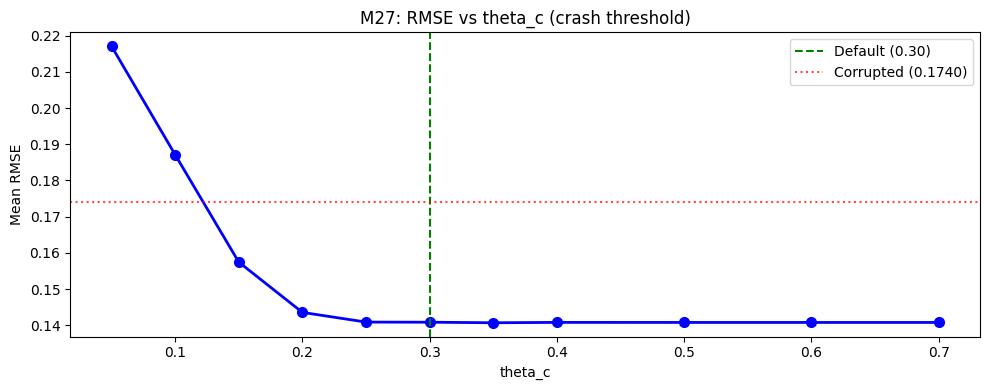

In [3]:
import matplotlib.pyplot as plt
from spm_reconstruct import get_model, Evaluator
from spm_eval.metrics import rmse

ev = Evaluator()

theta_c_vals = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30,
                0.35, 0.40, 0.50, 0.60, 0.70]
rmse_by_theta_c = []

for tc in theta_c_vals:
    model = get_model("(S6, CT, GC, P1)", params={'theta_c': tc})
    mean_rmse = np.mean([
        ev.evaluate(model.reconstruct(d), d)['rmse']
        for d in eval_images])
    rmse_by_theta_c.append(mean_rmse)
    print(f"  theta_c={tc:.2f}  RMSE={mean_rmse:.4f}")

# Corrupted baseline
baseline = np.mean([rmse(d.forward, d.true_surface) for d in eval_images])
default_idx = theta_c_vals.index(0.30)

plt.figure(figsize=(10, 4))
plt.plot(theta_c_vals, rmse_by_theta_c, 'bo-', lw=2, markersize=7)
plt.axvline(theta_c_vals[default_idx], color='green', ls='--',
            label=f'Default (0.30)')
plt.axhline(baseline, color='red', ls=':', alpha=0.7,
            label=f'Corrupted ({baseline:.4f})')
plt.xlabel('theta_c')
plt.ylabel('Mean RMSE')
plt.title('M27: RMSE vs theta_c (crash threshold)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Sweep gp_unc_thresh (GP activation)

`gp_unc_thresh` controls when the GP smoother fires.
Too low: over-smoothing (erases genuine surface features).
Too high: GP never fires (no lateral information flow).


  gp_unc_thresh=0.5  RMSE=0.1603
  gp_unc_thresh=1.0  RMSE=0.1570
  gp_unc_thresh=1.5  RMSE=0.1477
  gp_unc_thresh=2.0  RMSE=0.1447
  gp_unc_thresh=2.5  RMSE=0.1420
  gp_unc_thresh=3.0  RMSE=0.1409
  gp_unc_thresh=4.0  RMSE=0.1379
  gp_unc_thresh=5.0  RMSE=0.1352
  gp_unc_thresh=7.0  RMSE=0.1299
  gp_unc_thresh=10.0  RMSE=0.1231


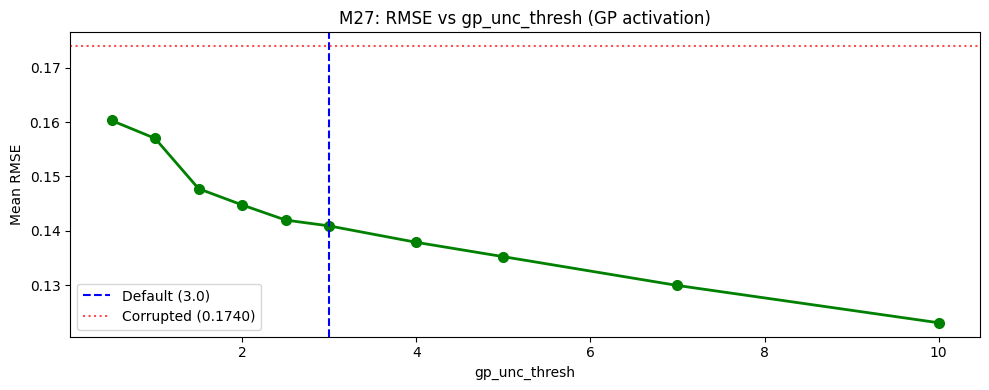

In [4]:
gp_vals  = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 10.0]
rmse_by_gp = []

for gp in gp_vals:
    model = get_model("(S6, CT, GC, P1)",
                      params={'gp_unc_thresh': gp})
    mean_rmse = np.mean([
        ev.evaluate(model.reconstruct(d), d)['rmse']
        for d in eval_images])
    rmse_by_gp.append(mean_rmse)
    print(f"  gp_unc_thresh={gp:.1f}  RMSE={mean_rmse:.4f}")

default_gp_idx = gp_vals.index(3.0)

plt.figure(figsize=(10, 4))
plt.plot(gp_vals, rmse_by_gp, 'go-', lw=2, markersize=7)
plt.axvline(gp_vals[default_gp_idx], color='blue', ls='--',
            label='Default (3.0)')
plt.axhline(baseline, color='red', ls=':', alpha=0.7,
            label=f'Corrupted ({baseline:.4f})')
plt.xlabel('gp_unc_thresh')
plt.ylabel('Mean RMSE')
plt.title('M27: RMSE vs gp_unc_thresh (GP activation)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Two-parameter grid

How do the two parameters interact?


  theta_c=0.15: [0.17868258 0.16855751 0.15747335 0.14737625]
  theta_c=0.25: [0.15811012 0.14478094 0.14091751 0.13517775]
  theta_c=0.35: [0.15602068 0.1445898  0.14073208 0.13508553]
  theta_c=0.50: [0.15611017 0.14476015 0.14081743 0.13517814]


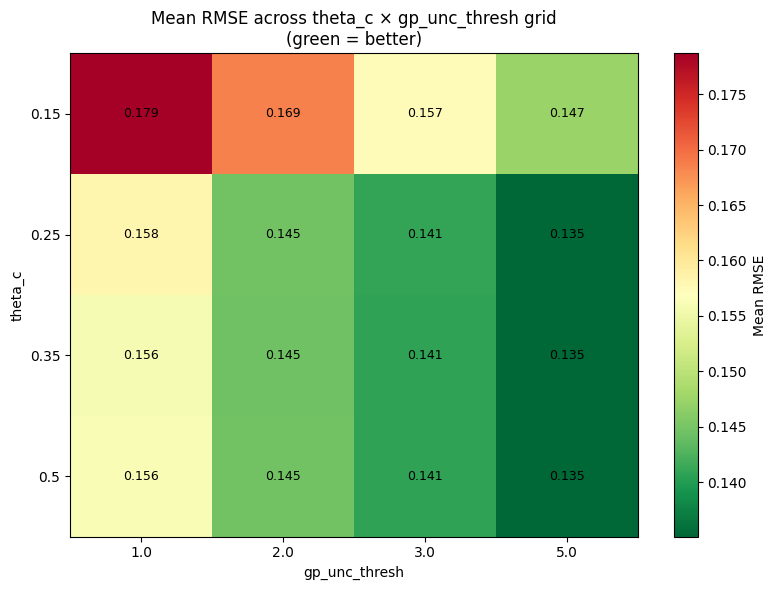


Best: theta_c=0.35  gp_unc_thresh=5.0  RMSE=0.1351


In [5]:
TC_GRID = [0.15, 0.25, 0.35, 0.50]
GP_GRID = [1.0, 2.0, 3.0, 5.0]

grid = np.zeros((len(TC_GRID), len(GP_GRID)))

for i, tc in enumerate(TC_GRID):
    for j, gp in enumerate(GP_GRID):
        model = get_model("(S6, CT, GC, P1)",
                          params={'theta_c': tc, 'gp_unc_thresh': gp})
        grid[i, j] = np.mean([
            ev.evaluate(model.reconstruct(d), d)['rmse']
            for d in eval_images])
    print(f"  theta_c={tc:.2f}: {grid[i]}")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(GP_GRID)))
ax.set_xticklabels(GP_GRID)
ax.set_yticks(range(len(TC_GRID)))
ax.set_yticklabels(TC_GRID)
ax.set_xlabel('gp_unc_thresh')
ax.set_ylabel('theta_c')
ax.set_title('Mean RMSE across theta_c × gp_unc_thresh grid\n'
             '(green = better)')

for i in range(len(TC_GRID)):
    for j in range(len(GP_GRID)):
        ax.text(j, i, f'{grid[i,j]:.3f}',
                ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=ax, label='Mean RMSE')
plt.tight_layout()
plt.show()

best = np.unravel_index(grid.argmin(), grid.shape)
print(f"\nBest: theta_c={TC_GRID[best[0]]}  "
      f"gp_unc_thresh={GP_GRID[best[1]]}  "
      f"RMSE={grid[best]:.4f}")

## 5. Which parameters matter most?

Compare the range of RMSE achieved by varying each parameter.
Large range = sensitive parameter (worth tuning carefully).
Small range = insensitive parameter (default is fine).


In [6]:
# Sensitivity = RMSE range across parameter grid
sens = {
    'theta_c':       max(rmse_by_theta_c) - min(rmse_by_theta_c),
    'gp_unc_thresh': max(rmse_by_gp)      - min(rmse_by_gp),
}

print("Parameter sensitivity (RMSE range across grid):")
for name, s in sorted(sens.items(), key=lambda x: -x[1]):
    bar = '█' * int(s * 500)
    print(f"  {name:<20}: {s:.4f}  {bar}")

Parameter sensitivity (RMSE range across grid):
  theta_c             : 0.0763  ██████████████████████████████████████
  gp_unc_thresh       : 0.0372  ██████████████████
